In [1]:
import sys
import os
os.chdir("/home/felixpersson/MasterThesisProject")
print(os.getcwd())

/home/felixpersson/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

import utils.sodium_properties as s_props
import data.dataclass as d_class

from pathlib import Path

from models.heatpipe.heat_pipe_limitations_model import HeatPipeLimitations
from models.heatpipe.liquid_discretised_model import LiquidDiscretised
from coupled.heatpipe import Heatpipe

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [5]:
def make_liquid_input(T_HP, T_v):
    """
    LiquidDiscretised expects one flat array:

        [flattened solid temperature field, scalar vapour temperature]

    The coupled Heatpipe solver may return T_HP either as:
        - flat array of shape (N_Z * N_R,)
        - 2D array of shape (N_Z, N_R)

    Therefore, we explicitly flatten it before appending T_v.
    """

    T_HP_flat = np.asarray(T_HP, dtype=float).reshape(-1)

    T_v_arr = np.asarray(T_v, dtype=float)
    T_v_scalar = float(np.mean(T_v_arr))

    T_liquid_input = np.concatenate([
        T_HP_flat,
        np.array([T_v_scalar], dtype=float),
    ])

    return T_liquid_input, T_v_scalar

In [6]:
from __future__ import annotations

import copy
import json
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import numpy as np

from utils import sodium_properties as s_props
from utils.solver import Solver

# Assumed to already exist in your notebook/project:
#
# generate_config
# Reactor
# VapourReactor
# LiquidDiscretised
# Heatpipe
# HeatPipeLimitations
# make_liquid_input
# d_class
# interpolator_model


# =====================================================================
# User-specific Q conversion
# =====================================================================

N_FUEL_PINS = 2970
HP_TO_FP_RATIO = 24.0 / 7.0


def thermal_power_to_plot_Q(P_th: float) -> float:
    """
    Converts total reactor thermal power to the heat-load value used in
    the Q--T limit plot.

    User definition:
        Q = P_th / 2970 * (24 / 7)
    """
    return float(P_th) / N_FUEL_PINS * HP_TO_FP_RATIO


# =====================================================================
# General helpers
# =====================================================================

def temperature_scalar(T_v: np.ndarray, T_v_scalar_from_liquid_input=None) -> float:
    """
    Characteristic temperature stored as T_i in the Q--T limit data.

    Current default:
        mean vapour temperature.
    """
    return float(np.mean(np.asarray(T_v, dtype=float)))


def align_like_velocity(u_v: np.ndarray, cell_values: np.ndarray) -> np.ndarray:
    """
    Aligns cell-centred quantities, such as c_s(T_v), with the vapour
    velocity grid.
    """
    u_v = np.asarray(u_v, dtype=float).reshape(-1)
    cell_values = np.asarray(cell_values, dtype=float).reshape(-1)

    n_u = len(u_v)
    n_c = len(cell_values)

    if n_u == n_c:
        return cell_values

    if n_u == n_c - 1:
        return 0.5 * (cell_values[:-1] + cell_values[1:])

    if n_u == n_c + 1:
        x_c = np.linspace(0.0, 1.0, n_c)
        x_u = np.linspace(0.0, 1.0, n_u)
        return np.interp(x_u, x_c, cell_values)

    x_c = np.linspace(0.0, 1.0, n_c)
    x_u = np.linspace(0.0, 1.0, n_u)
    return np.interp(x_u, x_c, cell_values)


def get_mesh_nr_nz(cfg_HP):
    """
    Reads N_R and N_Z from a heat-pipe config.

    Handles both:
        cfg_HP.mesh.N_R, cfg_HP.mesh.N_Z
    and:
        cfg_HP.N_R, cfg_HP.N_Z
    """
    mesh = getattr(cfg_HP, "mesh", cfg_HP)

    N_R = getattr(mesh, "N_R", None)
    N_Z = getattr(mesh, "N_Z", None)

    if N_R is None:
        N_R = getattr(cfg_HP, "N_R", None)

    if N_Z is None:
        N_Z = getattr(cfg_HP, "N_Z", None)

    if N_R is None or N_Z is None:
        raise AttributeError(
            "Could not find N_R and N_Z in cfg_HP. "
            "Check where mesh information is stored in your config object."
        )

    return int(N_R), int(N_Z)


def cfg_mesh_size(cfg_HP) -> int:
    N_R, N_Z = get_mesh_nr_nz(cfg_HP)
    return int(N_R * N_Z)


def build_heatpipe_config_from_data(
    data: dict,
    *,
    N_R: int,
    N_Z: int,
    h_cond: float,
):
    """
    Builds a standalone heat-pipe config used by LiquidDiscretised,
    Heatpipe, and HeatPipeLimitations.
    """
    data = copy.deepcopy(data)
    data["HeatPipe"]["material"]["h_cond"] = float(h_cond)

    geom = d_class.HeatpipeGeometry(**data["HeatPipe"]["geometry"])
    mesh = d_class.HeatpipeMesh(N_R=int(N_R), N_Z=int(N_Z))
    mat = d_class.HeatpipeMaterial(**data["HeatPipe"]["material"])
    bc = d_class.HeatpipeBC(**data["HeatPipe"]["bc"])
    wick = d_class.HeatpipeWick(**data["HeatPipe"]["wick"])

    cfg = d_class.HeatpipeConfig(geom, mesh, mat, wick, bc)
    cfg_HP = cfg.resolve_geometry()

    HP = Heatpipe(cfg_HP)

    return cfg_HP, HP


def rebuild_cfg_HP_to_match_solid_temperature(
    *,
    data: dict,
    reference_cfg_HP,
    h_cond: float,
    T_solid: np.ndarray,
):
    """
    Rebuilds cfg_HP so that cfg_HP.mesh.N_R * cfg_HP.mesh.N_Z matches
    T_solid.size.

    This fixes errors like:

        cannot reshape array of size 345 into shape (20,15)

    because 345 = 15 * 23, while the old cfg expected 15 * 20.
    """
    T_solid = np.asarray(T_solid)
    target_size = int(T_solid.size)

    old_N_R, old_N_Z = get_mesh_nr_nz(reference_cfg_HP)
    old_size = old_N_R * old_N_Z

    if old_size == target_size:
        return reference_cfg_HP, None

    candidates = []

    # Most likely case: radial resolution unchanged, axial resolution changed.
    if target_size % old_N_R == 0:
        candidates.append((old_N_R, target_size // old_N_R))

    # Alternative case: axial resolution unchanged, radial resolution changed.
    if target_size % old_N_Z == 0:
        candidates.append((target_size // old_N_Z, old_N_Z))

    unique_candidates = []
    for candidate in candidates:
        if candidate not in unique_candidates:
            unique_candidates.append(candidate)

    for N_R_new, N_Z_new in unique_candidates:
        try:
            cfg_HP_new, HP_new = build_heatpipe_config_from_data(
                data,
                N_R=N_R_new,
                N_Z=N_Z_new,
                h_cond=h_cond,
            )

            new_size = cfg_mesh_size(cfg_HP_new)

            if new_size == target_size:
                print(
                    "  Rebuilt cfg_HP to match reactor solution: "
                    f"old mesh=({old_N_R}, {old_N_Z}), "
                    f"new mesh=({N_R_new}, {N_Z_new}), "
                    f"T_solid.size={target_size}"
                )
                return cfg_HP_new, HP_new

        except Exception as exc:
            print(
                f"  Tried rebuilding cfg_HP with "
                f"N_R={N_R_new}, N_Z={N_Z_new}, but failed: {exc}"
            )

    raise ValueError(
        "Could not rebuild cfg_HP to match T_solid size. "
        f"T_solid.size={target_size}, old cfg mesh=({old_N_R}, {old_N_Z}), "
        f"old size={old_size}. Candidates tried: {unique_candidates}"
    )


# =====================================================================
# Data containers
# =====================================================================

@dataclass
class ReactorLimitPoint:
    P_th: float
    h_cond: float
    Q_plot: float
    T_plot: float

    max_mach: float
    capillary_pressure_required: float
    capillary_pressure_max: float
    capillary_margin: float

    T_v: np.ndarray
    T_solid: np.ndarray
    u_v: np.ndarray
    mach_profile: np.ndarray
    delta_p_profile: np.ndarray


@dataclass
class RootResult:
    point: Optional[ReactorLimitPoint]
    residual: float
    status: str
    n_solves: int


# =====================================================================
# Main solver
# =====================================================================

class ReactorHeatPipeLimitSolver:
    """
    Computes analytic and numerical heat-pipe operating limits for the
    coupled reactor model.

    Analytic limits:
        - sonic
        - entrainment
        - boiling

    Numerical limits:
        - sonic
        - capillary

    Numerical search:
        Uses continuation/marching in power instead of bisection.
    """

    def __init__(
        self,
        *,
        reactor_data_path: str | Path = "./data/reactor_data.json",
        Ns=(15, 15, 20),
        cfg_HP=None,
        HP=None,
        interpolator_model=None,
        h_cond_values=None,
        P_start: float = 12.0e6,
        Delta_P_start: float = 0.10e6,
        Delta_P_min: float = 0.01e6,
        Delta_P_max: float = 0.50e6,
        max_marching_iter: int = 80,
        growth_factor: float = 1.10,
        shrink_factor: float = 0.50,
        analytic_T_span=(700.0, 1400.0),
        n_analytic_T: int = 100,
        output_path: str | Path = "./heatpipe_limit_curves.npz",
        checkpoint_path: str | Path = "./heatpipe_limit_curves_checkpoint.npz",
        store_profiles: bool = True,
    ):
        self.reactor_data_path = Path(reactor_data_path)
        self.Ns = tuple(Ns)

        with open(self.reactor_data_path, "r") as f:
            self.base_data = json.load(f)

        if cfg_HP is None or HP is None:
            cfg_HP, HP = build_heatpipe_config_from_data(
                self.base_data,
                N_R=15,
                N_Z=20,
                h_cond=550.0,
            )

        self.cfg_HP = cfg_HP
        self.HP = HP
        self.interpolator_model = interpolator_model

        if h_cond_values is None:
            h_cond_values = np.linspace(400.0, 1200.0, 8)

        self.h_cond_values = np.asarray(h_cond_values, dtype=float)

        self.P_start = float(P_start)
        self.Delta_P_start = float(Delta_P_start)
        self.Delta_P_min = float(Delta_P_min)
        self.Delta_P_max = float(Delta_P_max)
        self.max_marching_iter = int(max_marching_iter)
        self.growth_factor = float(growth_factor)
        self.shrink_factor = float(shrink_factor)

        self.analytic_T_span = tuple(float(x) for x in analytic_T_span)
        self.n_analytic_T = int(n_analytic_T)

        self.output_path = Path(output_path)
        self.checkpoint_path = Path(checkpoint_path)

        self.store_profiles = bool(store_profiles)

        self._cache: dict[tuple[float, float], ReactorLimitPoint] = {}

    # -----------------------------------------------------------------
    # Coupled reactor solve
    # -----------------------------------------------------------------

    def solve_reactor_point(self, P_th: float, h_cond: float) -> ReactorLimitPoint:
        """
        Runs the full coupled reactor at a given thermal power and condenser
        heat-transfer coefficient.
        """
        P_th = float(P_th)
        h_cond = float(h_cond)

        cache_key = (round(P_th, 6), round(h_cond, 6))
        if cache_key in self._cache:
            return self._cache[cache_key]

        data = copy.deepcopy(self.base_data)
        data["HeatPipe"]["material"]["h_cond"] = h_cond
        data["Reactor"]["power"]["thermal"] = P_th

        cfg = generate_config(data, *self.Ns)

        iso_reactor = Reactor(cfg)
        vap_reactor_800 = VapourReactor(cfg)
        vap_reactor = VapourReactor(cfg)
        vap_reactor_full = VapourReactor(cfg)

        vap_reactor.heatpipe.solid.k_temperature = 1100

        # if self.interpolator_model is not None:
        #     vap_reactor_full.set_interpolator_model(self.interpolator_model)

        vap_reactor_full.set_variable_k(True)

        solver_vap = Solver(
            [
                vap_reactor_800,
                vap_reactor,
                vap_reactor_full,
            ],
            iterate=True,
        )

        solver_vap.fsolve()

        ((T_solid, u_v, T_v), T_FP, (phi_n_g, k)) = solver_vap.solutions[2]

        T_solid = np.asarray(T_solid, dtype=float)
        u_v = np.asarray(u_v, dtype=float)
        T_v = np.asarray(T_v, dtype=float)

        print(
            f"  solved: P_th={P_th:.6e} W, h_cond={h_cond:.3f}, "
            f"T_v=[{np.min(T_v):.2f}, {np.max(T_v):.2f}] K, "
            f"T_solid.size={T_solid.size}, T_v.size={T_v.size}"
        )

        # -------------------------------------------------------------
        # Match cfg_HP to actual reactor mesh.
        # -------------------------------------------------------------
        cfg_HP_run, HP_run = rebuild_cfg_HP_to_match_solid_temperature(
            data=data,
            reference_cfg_HP=self.cfg_HP,
            h_cond=h_cond,
            T_solid=T_solid,
        )

        if HP_run is None:
            HP_run = self.HP

        # -------------------------------------------------------------
        # Mach number
        # -------------------------------------------------------------
        c_s = np.asarray(HP_run._calculate_c_s(T_v), dtype=float)
        c_s_on_u_grid = align_like_velocity(u_v, c_s)

        mach_profile = np.abs(u_v.reshape(-1)) / c_s_on_u_grid.reshape(-1)
        max_mach = float(np.nanmax(mach_profile))

        # -------------------------------------------------------------
        # Liquid/vapour pressure profiles for capillary criterion
        # -------------------------------------------------------------
        T_liquid_input, T_v_scalar_from_liquid = make_liquid_input(T_solid, T_v)

        T_HP_full = (T_solid, u_v, T_v)

        liquid = LiquidDiscretised(
            cfg_HP_run,
            T_HP_full,
        )

        # liquid.print_mdot_diagnostics(
        #     label=f"P_th={P_th:.3e} W, h_cond={h_cond:.3f}"
        # )

        P_l = liquid.get_pressure_drop_profile()
        P_v = s_props.calculate_Na_pressure_v(T_v)

        P_l = np.asarray(P_l, dtype=float).reshape(-1)
        P_v = np.asarray(P_v, dtype=float).reshape(-1)

        if len(P_l) != len(P_v):
            raise ValueError(
                "Pressure-profile length mismatch: "
                f"len(P_l)={len(P_l)}, len(P_v)={len(P_v)}. "
                "Check that cfg_HP_run has the same axial mesh as the "
                "reactor heat-pipe model."
            )

        # Shift both profiles to start at zero.
        P_v = P_v - P_v[0]
        print(f"Maximum pressure drop: {np.max(np.abs(P_v))}")

        P_l = P_l - P_l[0]

        # Reverse liquid pressure profile so it can be compared against the
        # vapour profile in the same axial direction.
        P_l_rev = P_l[::-1]

        # Shift vapour profile until it just touches the liquid profile.
        shift_touch = np.min(P_v - P_l_rev)
        P_v_touch = P_v - shift_touch

        # Difference between the shifted profiles.
        diff = P_v_touch - P_l_rev

        # Numerical tolerance: after shifting, diff should be >= 0 up to roundoff.
        if np.nanmin(diff) < -1e-8:
            print(
                "Warning: shifted vapour/liquid pressure profiles overlap. "
                f"min(diff)={np.nanmin(diff):.6e}"
            )

        # Wet/contact point.
        i_contact = int(np.nanargmin(np.abs(diff)))

        # Use the same construction as the Busse-style analytical method.
        shift_zero = P_v_touch[0]

        P_v_plot = P_v_touch - shift_zero
        P_l_plot = P_l_rev - shift_zero

        Delta_P_profile_v_l = np.concatenate([
            P_v_plot[:i_contact + 1],
            P_l_plot[:i_contact + 1][::-1],
        ])

        capillary_pressure_required = float(
            Delta_P_profile_v_l[0] - Delta_P_profile_v_l[-1]
        )

        # Keep this for diagnostics/plotting.
        delta_p_profile = diff

        # Maximum available capillary pressure.
        T_cap = temperature_scalar(T_v, T_v_scalar_from_liquid)
        sigma_l = s_props.calculate_Na_surface_tension(T_cap)

        capillary_pressure_max = float(
            2.0 * sigma_l / cfg_HP_run.wick.r_pore
        )

        capillary_margin = capillary_pressure_max - capillary_pressure_required

        T_plot = temperature_scalar(T_v, T_v_scalar_from_liquid)
        Q_plot = thermal_power_to_plot_Q(P_th)

        point = ReactorLimitPoint(
            P_th=P_th,
            h_cond=h_cond,
            Q_plot=Q_plot,
            T_plot=T_plot,
            max_mach=max_mach,
            capillary_pressure_required=capillary_pressure_required,
            capillary_pressure_max=capillary_pressure_max,
            capillary_margin=capillary_margin,
            T_v=T_v,
            T_solid=T_solid,
            u_v=u_v,
            mach_profile=mach_profile,
            delta_p_profile=delta_p_profile,
        )

        print(
            f"  post: Q={Q_plot:.6e} W, T={T_plot:.2f} K, "
            f"max_mach={max_mach:.6e}, "
            f"cap_margin={capillary_margin:.6e} Pa, "
            f"Pressure loss={capillary_pressure_required:.6e} Pa, "
            f"Pressure head={capillary_pressure_max:.6e} Pa, "
        )

        
        # -------------------------------------------------------------
        # Diagnostic pressure-drop printout
        # -------------------------------------------------------------
        Delta_P_l_signed = float(P_l[-1] - P_l[0])
        Delta_P_v_signed = float(P_v[-1] - P_v[0])

        Delta_P_l_abs = abs(Delta_P_l_signed)
        Delta_P_v_abs = abs(Delta_P_v_signed)

        print(
            f"  pressure drops: "
            f"Delta_P_l={Delta_P_l_signed:.6e} Pa "
            f"(|Delta_P_l|={Delta_P_l_abs:.6e} Pa), "
            f"Delta_P_v={Delta_P_v_signed:.6e} Pa "
            f"(|Delta_P_v|={Delta_P_v_abs:.6e} Pa)"
        )


        self._cache[cache_key] = point
        return point
    # -----------------------------------------------------------------
    # Margin definitions
    # -----------------------------------------------------------------

    @staticmethod
    def sonic_margin(point: ReactorLimitPoint) -> float:
        """
        Positive means below sonic limit.
        Zero means at sonic limit.
        Negative means above sonic limit.
        """
        return 1.0 - point.max_mach

    @staticmethod
    def capillary_margin_fn(point: ReactorLimitPoint) -> float:
        """
        Positive means below capillary limit.
        Zero means at capillary limit.
        Negative means above capillary limit.
        """
        return point.capillary_pressure_max - point.capillary_pressure_required

    # -----------------------------------------------------------------
    # Marching limit solve
    # -----------------------------------------------------------------

    def solve_power_for_limit_marching(
        self,
        *,
        h_cond: float,
        margin_fn: Callable[[ReactorLimitPoint], float],
        limit_name: str,
        P_start: Optional[float] = None,
        Delta_P_start: Optional[float] = None,
        Delta_P_min: Optional[float] = None,
        Delta_P_max: Optional[float] = None,
        power_direction: float = 1.0,
    ) -> RootResult:
        """
        Marches reactor power upward until a limit is crossed.

        This avoids bisection because the reactor is only stable in a narrow
        region.
        """
        h_cond = float(h_cond)

        if P_start is None:
            P_start = self.P_start
        if Delta_P_start is None:
            Delta_P_start = self.Delta_P_start
        if Delta_P_min is None:
            Delta_P_min = self.Delta_P_min
        if Delta_P_max is None:
            Delta_P_max = self.Delta_P_max

        P = float(P_start)
        Delta_P = float(Delta_P_start)

        n_solves = 0

        previous_point = None
        previous_margin = None
        previous_P = None

        best_point = None
        best_margin = np.inf

        # -------------------------------------------------------------
        # Find valid starting point.
        # -------------------------------------------------------------
        while True:
            try:
                point = self.solve_reactor_point(P, h_cond)
                n_solves += 1
                margin = float(margin_fn(point))

                previous_point = point
                previous_margin = margin
                previous_P = P

                best_point = point
                best_margin = margin

                print(
                    f"  start accepted: P={P:.6e} W, "
                    f"Q={point.Q_plot:.6e} W, "
                    f"T={point.T_plot:.2f} K, "
                    f"margin={margin:.6e}"
                )

                break

            except Exception as exc:
                n_solves += 1

                print(
                    f"  start failed: P={P:.6e} W, "
                    f"h_cond={h_cond:.3f}, error={exc}"
                )

                P *= 1.1

                if P < 1.0e6:
                    return RootResult(
                        point=None,
                        residual=np.nan,
                        status=(
                            f"{limit_name}: could not find a converged "
                            f"starting point"
                        ),
                        n_solves=n_solves,
                    )

        # -------------------------------------------------------------
        # Find a valid starting point that is BELOW the limit.
        #
        # For the sonic case with power_direction = -1:
        #   - normal marching direction is downward in power
        #   - if we start above Mach 1, we must move upward in power
        #     until max_mach < 1 before marching downward again
        # -------------------------------------------------------------

        P = float(P_start)
        Delta_P = float(Delta_P_start)

        previous_point = None
        previous_margin = None
        previous_P = None

        best_point = None
        best_margin = np.inf

        max_start_iter = 30

        for j_start in range(max_start_iter):

            try:
                point = self.solve_reactor_point(P, h_cond)
                n_solves += 1
                margin = float(margin_fn(point))

                print(
                    f"  start search {j_start:03d}: P={P:.6e} W, "
                    f"Q={point.Q_plot:.6e} W, "
                    f"T={point.T_plot:.2f} K, "
                    f"margin={margin:.6e}"
                )

                # Track the point closest to the limit, even if it is above.
                if abs(margin) < abs(best_margin):
                    best_point = point
                    best_margin = margin

                # Found a valid below-limit starting point.
                if margin > 0.0:
                    previous_point = point
                    previous_margin = margin
                    previous_P = P

                    print(
                        f"  start accepted below limit: P={P:.6e} W, "
                        f"margin={margin:.6e}"
                    )

                    break

                # If the point is above the limit, move opposite to the
                # marching direction to get back below the limit.
                #
                # Example for sonic:
                #   power_direction = -1 means the limit search marches downward.
                #   If we are already above Mach 1, move upward instead.
                P = P - power_direction * Delta_P
                Delta_P = min(Delta_P * self.growth_factor, float(Delta_P_max))

            except Exception as exc:
                n_solves += 1

                print(
                    f"  start search failed {j_start:03d}: P={P:.6e} W, "
                    f"h_cond={h_cond:.3f}, error={exc}"
                )

                # Do NOT blindly do P *= 0.9.
                # Move opposite to the marching direction.
                P = P - power_direction * Delta_P
                Delta_P = min(Delta_P * self.growth_factor, float(Delta_P_max))

        else:
            return RootResult(
                point=best_point,
                residual=best_margin,
                status=(
                    f"{limit_name}: could not find a below-limit starting point; "
                    f"returning closest valid point"
                ),
                n_solves=n_solves,
            )

        # -------------------------------------------------------------
        # March upward in power.
        # -------------------------------------------------------------
        for i in range(self.max_marching_iter):

            P_trial = previous_P + power_direction * Delta_P

            try:
                point = self.solve_reactor_point(P_trial, h_cond)
                n_solves += 1
                margin = float(margin_fn(point))

                print(
                    f"  iter {i:03d}: P={P_trial:.6e} W, "
                    f"Q={point.Q_plot:.6e} W, "
                    f"T={point.T_plot:.2f} K, "
                    f"margin={margin:.6e}, "
                    f"Delta_P={Delta_P:.3e}"
                )

                if abs(margin) < abs(best_margin):
                    best_point = point
                    best_margin = margin

                # Limit crossed.
                if previous_margin * margin < 0.0:
                    alpha = previous_margin / (previous_margin - margin)

                    P_cross = previous_P + alpha * (P_trial - previous_P)
                    Q_cross = (
                        previous_point.Q_plot
                        + alpha * (point.Q_plot - previous_point.Q_plot)
                    )
                    T_cross = (
                        previous_point.T_plot
                        + alpha * (point.T_plot - previous_point.T_plot)
                    )

                    crossing_point = copy.deepcopy(previous_point)
                    crossing_point.P_th = float(P_cross)
                    crossing_point.Q_plot = float(Q_cross)
                    crossing_point.T_plot = float(T_cross)

                    crossing_point.max_mach = float(
                        previous_point.max_mach
                        + alpha * (point.max_mach - previous_point.max_mach)
                    )

                    crossing_point.capillary_pressure_required = float(
                        previous_point.capillary_pressure_required
                        + alpha
                        * (
                            point.capillary_pressure_required
                            - previous_point.capillary_pressure_required
                        )
                    )

                    crossing_point.capillary_pressure_max = float(
                        previous_point.capillary_pressure_max
                        + alpha
                        * (
                            point.capillary_pressure_max
                            - previous_point.capillary_pressure_max
                        )
                    )

                    crossing_point.capillary_margin = float(
                        crossing_point.capillary_pressure_max
                        - crossing_point.capillary_pressure_required
                    )

                    return RootResult(
                        point=crossing_point,
                        residual=0.0,
                        status=f"{limit_name}: crossed limit by marching",
                        n_solves=n_solves,
                    )

                # Still below limit. Accept point and continue.
                if margin > 0.0:
                    previous_P = P_trial
                    previous_point = point
                    previous_margin = margin

                    Delta_P = min(
                        Delta_P * self.growth_factor,
                        float(Delta_P_max),
                    )
                    continue

                return RootResult(
                    point=point,
                    residual=margin,
                    status=f"{limit_name}: reached limit",
                    n_solves=n_solves,
                )

            except Exception as exc:
                n_solves += 1

                print(
                    f"  trial failed: P={P_trial:.6e} W, "
                    f"h_cond={h_cond:.3f}, "
                    f"Delta_P={Delta_P:.3e}, error={exc}"
                )

                Delta_P *= self.shrink_factor

                if Delta_P < Delta_P_min:
                    return RootResult(
                        point=best_point,
                        residual=best_margin,
                        status=(
                            f"{limit_name}: reactor failed before a limit "
                            f"crossing could be resolved; returning closest "
                            f"stable point"
                        ),
                        n_solves=n_solves,
                    )

        return RootResult(
            point=best_point,
            residual=best_margin,
            status=f"{limit_name}: maximum marching iterations reached",
            n_solves=n_solves,
        )

    # -----------------------------------------------------------------
    # Analytic limits
    # -----------------------------------------------------------------

    def compute_analytic_limits(self) -> dict[str, np.ndarray]:
        """
        Computes analytic sonic, entrainment, and boiling limits.
        """
        T_span = np.linspace(
            self.analytic_T_span[0],
            self.analytic_T_span[1],
            self.n_analytic_T,
        )

        HP_limits = HeatPipeLimitations(self.HP, self.cfg_HP)

        Q_sonic = HP_limits.calculate_analytical_sonic_limit(T_span)
        Q_entrainment = HP_limits.calculate_analytical_entrainment_limit(T_span)
        Q_boiling = HP_limits.calculate_analytical_boiling_limit_new(T_span)

        out = {
            "analytic_T": np.asarray(T_span, dtype=float),
            "sonic_analytic_Q": np.asarray(Q_sonic, dtype=float),
            "entrainment_analytic_Q": np.asarray(Q_entrainment, dtype=float),
            "boiling_analytic_Q": np.asarray(Q_boiling, dtype=float),
        }

        # if hasattr(HP_limits, "calculate_analytical_capillary_limit"):
        #     out["capillary_analytic_Q"] = np.asarray(
        #         HP_limits.calculate_analytical_capillary_limit(T_span),
        #         dtype=float,
        #     )

        return out

    # -----------------------------------------------------------------
    # Numerical curves
    # -----------------------------------------------------------------

    def compute_numeric_curve_marching(
    self,
    *,
    limit_name: str,
    margin_fn: Callable[[ReactorLimitPoint], float],
    P_start: Optional[float] = None,
    Delta_P_start: Optional[float] = None,
    Delta_P_min: Optional[float] = None,
    Delta_P_max: Optional[float] = None,
    power_direction: float = 1.0,
    use_h_continuation: bool = True,
    ) -> dict[str, np.ndarray]:
        """
        Computes a numerical limit curve by sweeping h_cond and marching
        reactor power until the chosen limit is crossed.

        Parameters
        ----------
        power_direction:
            +1.0 means march upward in reactor power.
            -1.0 means march downward in reactor power.

        use_h_continuation:
            If True, the previous successful limit point is used as the
            starting power for the next h_cond value.

            The starting point is only updated if the previous search actually
            crossed/reached the limit. This avoids propagating a bad fallback
            point when the reactor fails before a limit crossing.
        """
        points = []
        residuals = []
        statuses = []
        n_solves_list = []

        t0 = time.time()

        if P_start is None:
            current_P_start = self.P_start
        else:
            current_P_start = float(P_start)

        for j, h_cond in enumerate(self.h_cond_values):
            print(
                f"\n[{limit_name}] h_cond point {j + 1}/{len(self.h_cond_values)}: "
                f"h_cond={h_cond:.6g}"
            )

            result = self.solve_power_for_limit_marching(
                h_cond=float(h_cond),
                margin_fn=margin_fn,
                limit_name=limit_name,
                P_start=current_P_start,
                Delta_P_start=Delta_P_start,
                Delta_P_min=Delta_P_min,
                Delta_P_max=Delta_P_max,
                power_direction=power_direction,
            )

            points.append(result.point)
            residuals.append(result.residual)
            statuses.append(result.status)
            n_solves_list.append(result.n_solves)

            if result.point is not None:
                print(
                    f"  status: {result.status}\n"
                    f"  P_th  = {result.point.P_th:.6e} W\n"
                    f"  Q     = {result.point.Q_plot:.6e} W\n"
                    f"  T     = {result.point.T_plot:.6f} K\n"
                    f"  resid = {result.residual:.6e}\n"
                    f"  solves this point = {result.n_solves}"
                )

                # Only continue from this power if the previous h_cond search
                # actually found the limit. Do not continue from fallback points.
                successful_limit = (
                    "crossed limit" in result.status
                    or "reached limit" in result.status
                    or abs(result.residual) < 1.0e-3
                )

                if use_h_continuation and successful_limit:
                    current_P_start = result.point.P_th

            else:
                print(f"  status: {result.status}")

            elapsed = time.time() - t0
            print(f"  elapsed for {limit_name}: {elapsed / 60.0:.2f} min")

        prefix = f"{limit_name}_numeric"

        data = {
            f"{prefix}_h_cond": np.asarray(self.h_cond_values, dtype=float),
            f"{prefix}_P_th": np.asarray(
                [p.P_th if p is not None else np.nan for p in points],
                dtype=float,
            ),
            f"{prefix}_Q": np.asarray(
                [p.Q_plot if p is not None else np.nan for p in points],
                dtype=float,
            ),
            f"{prefix}_T": np.asarray(
                [p.T_plot if p is not None else np.nan for p in points],
                dtype=float,
            ),
            f"{prefix}_residual": np.asarray(residuals, dtype=float),
            f"{prefix}_status": np.asarray(statuses, dtype=str),
            f"{prefix}_n_solves": np.asarray(n_solves_list, dtype=int),
            f"{prefix}_power_direction": np.asarray(power_direction, dtype=float),
        }

        if limit_name == "sonic":
            data[f"{prefix}_max_mach"] = np.asarray(
                [p.max_mach if p is not None else np.nan for p in points],
                dtype=float,
            )

        if limit_name == "capillary":
            data[f"{prefix}_pressure_required"] = np.asarray(
                [
                    p.capillary_pressure_required if p is not None else np.nan
                    for p in points
                ],
                dtype=float,
            )
            data[f"{prefix}_pressure_max"] = np.asarray(
                [
                    p.capillary_pressure_max if p is not None else np.nan
                    for p in points
                ],
                dtype=float,
            )
            data[f"{prefix}_margin"] = np.asarray(
                [
                    p.capillary_margin if p is not None else np.nan
                    for p in points
                ],
                dtype=float,
            )

        if self.store_profiles:
            data[f"{prefix}_T_v_profiles"] = np.asarray(
                [p.T_v if p is not None else np.array([]) for p in points],
                dtype=object,
            )
            data[f"{prefix}_T_solid_profiles"] = np.asarray(
                [p.T_solid if p is not None else np.array([]) for p in points],
                dtype=object,
            )
            data[f"{prefix}_mach_profiles"] = np.asarray(
                [p.mach_profile if p is not None else np.array([]) for p in points],
                dtype=object,
            )
            data[f"{prefix}_delta_p_profiles"] = np.asarray(
                [p.delta_p_profile if p is not None else np.array([]) for p in points],
                dtype=object,
            )

        return data

    # -----------------------------------------------------------------
    # Save
    # -----------------------------------------------------------------

    def save_results(self, results: dict[str, np.ndarray], path: str | Path):
        metadata = {
            "reactor_data_path": str(self.reactor_data_path),
            "Ns": self.Ns,
            "h_cond_values": self.h_cond_values.tolist(),
            "P_start": self.P_start,
            "Delta_P_start": self.Delta_P_start,
            "Delta_P_min": self.Delta_P_min,
            "Delta_P_max": self.Delta_P_max,
            "max_marching_iter": self.max_marching_iter,
            "growth_factor": self.growth_factor,
            "shrink_factor": self.shrink_factor,
            "Q_conversion": "Q = P_th / 2970 * (24 / 7)",
            "numeric_sonic_margin": "1 - max(abs(u_v) / c_s(T_v))",
            "numeric_capillary_margin": "Delta_p_cap_max - Delta_p_required",
            "Delta_p_cap_max": "2 * sigma_l / r_pore",
            "T_plot_definition": "mean vapour temperature by default",
            "store_profiles": self.store_profiles,
        }

        results = dict(results)
        results["metadata_json"] = np.asarray(json.dumps(metadata, indent=2))

        np.savez(path, **results)

    # -----------------------------------------------------------------
    # Full run
    # -----------------------------------------------------------------

    def run(self) -> dict[str, np.ndarray]:
        """
        Runs all requested limits and stores them in output_path.
        """
        results: dict[str, np.ndarray] = {}

        print("\nComputing analytic heat-pipe limits...")
        analytic = self.compute_analytic_limits()
        results.update(analytic)
        self.save_results(results, self.checkpoint_path)
        
        # print("\nComputing numerical capillary limit...")
        # capillary_numeric = self.compute_numeric_curve_marching(
        #     limit_name="capillary",
        #     margin_fn=self.capillary_margin_fn,
        #     power_direction=1.0,
        #     use_h_continuation=True,
        # )
        # results.update(capillary_numeric)

        print("\nComputing numerical sonic limit...")
        sonic_numeric = self.compute_numeric_curve_marching(
            limit_name="sonic",
            margin_fn=self.sonic_margin,
            power_direction=-1.0,
            use_h_continuation=True,
        )
        results.update(sonic_numeric)
        self.save_results(results, self.checkpoint_path)


        self.save_results(results, self.output_path)

        print(f"\nSaved final limit data to: {self.output_path}")
        print(f"Saved checkpoint data to:  {self.checkpoint_path}")

        return results

In [9]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

with open("./data/reactor_data.json", "r") as f:
    base_data = json.load(f)

cfg_HP, HP = build_heatpipe_config_from_data(
    base_data,
    N_R=15,
    N_Z=23,
    h_cond=550.0,
)

h_cond_values = np.linspace(75.0, 1800.0, 25)
# h_cond_values = np.append(h_cond_values, [30.0, 50.0])
# h_cond_values = np.sort(h_cond_values)

limit_solver = ReactorHeatPipeLimitSolver(
    reactor_data_path="./data/reactor_data.json",
    Ns=(15, 15, 23),
    cfg_HP=cfg_HP,
    HP=HP,
    interpolator_model=interpolator_model,

    # Sweep condenser h to generate the numerical Q--T curve.
    h_cond_values=h_cond_values,

    # Continuation/marching settings.
    P_start=1.0e6,
    Delta_P_start=0.10e6,
    Delta_P_min=0.01e6,
    Delta_P_max=0.50e6,
    max_marching_iter=80,
    growth_factor=1.10,
    shrink_factor=0.50,

    analytic_T_span=(700.0, 1500.0),
    n_analytic_T=100,

    output_path=f"./heatpipe_limit_curves_{timestamp}.npz",
    checkpoint_path=f"./heatpipe_limit_curves_checkpoint_{timestamp}.npz",
    store_profiles=True,
)

results = limit_solver.run()


Computing analytic heat-pipe limits...
{'invalid_property_points': 0, 'non_positive_superheat_points': 0, 'non_finite_result_points': 0}

Computing numerical sonic limit...

[sonic] h_cond point 1/25: h_cond=75
Mesh warning: Fuel pin N_Z changed from 10 to 15
Mesh warning: Neutronics N_Z changed from 10 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.
Running iteration 3 ...
fsolve message: The solution converged.
  solved: P_th=1.000000e+06 W, h_cond=75.000, T_v=[590.89, 813.53] K, T_solid.size=345, T_v.size=23
Maximum pressure drop: 1209.7057657592304
  post: Q=1.154401e+03 W, T=768.60 K, max_mach=1.600012e+00, cap_margin=1.458692e+04 Pa, Pressure loss=1.327535e+03 Pa, Pressure head=1.591445e+04 Pa, 
  pressure drops: Delta_P_l=-1.178290e+02 Pa (|Delta_P_l|=1.178290e+02 Pa), Delta_P_v=-1.209706e+03 Pa (|Delta_P_v|=1.209706e+03 

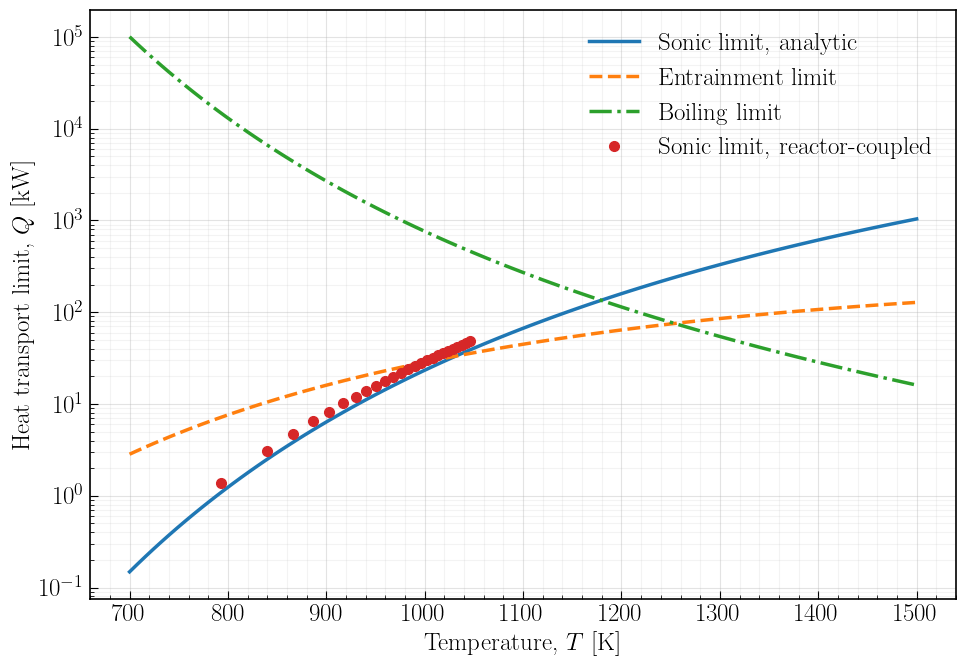

In [23]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
data = np.load("./heatpipe_limit_curves_20260530_1848.npz", allow_pickle=True)


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 18,
    "text.usetex": True,
})


def finite_xy(x, y):
    """Return only finite x/y pairs."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def maybe_plot_line(key_T, key_Q, label, *, linestyle="-", linewidth=2.5):
    """Plot a line if both keys exist."""
    if key_T in data and key_Q in data:
        T, Q = finite_xy(data[key_T], data[key_Q])
        if len(T) > 0:
            plt.plot(T, Q / 1e3, linestyle=linestyle, linewidth=linewidth, label=label)


def maybe_plot_points(key_T, key_Q, label, *, marker="o", markersize=7):
    """Plot points if both keys exist."""
    if key_T in data and key_Q in data:
        T, Q = finite_xy(data[key_T], data[key_Q])
        if len(T) > 0:
            plt.plot(
                T,
                Q / 1e3,
                linestyle="none",
                marker=marker,
                markersize=markersize,
                label=label,
            )


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

plt.sca(ax)

# Analytic limits
maybe_plot_line(
    "analytic_T",
    "sonic_analytic_Q",
    r"Sonic limit, analytic",
    linestyle="-",
)

maybe_plot_line(
    "analytic_T",
    "entrainment_analytic_Q",
    r"Entrainment limit",
    linestyle="--",
)

maybe_plot_line(
    "analytic_T",
    "boiling_analytic_Q",
    r"Boiling limit",
    linestyle="-.",
)

# Optional, only if you later store analytical capillary data
maybe_plot_line(
    "analytic_T",
    "capillary_analytic_Q",
    r"Capillary limit, analytic",
    linestyle=":",
)

# Numerical reactor-coupled limits
maybe_plot_points(
    "sonic_numeric_T",
    "sonic_numeric_Q",
    r"Sonic limit, reactor-coupled",
    marker="o",
)

maybe_plot_points(
    "capillary_numeric_T",
    "capillary_numeric_Q",
    r"Capillary limit, reactor-coupled",
    marker="s",
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(r"Temperature, $T$ [K]")
ax.set_ylabel(r"Heat transport limit, $Q$ [kW]")

ax.set_yscale("log")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)
ax.minorticks_on()

ax.legend(
    frameon=False,
    loc="best",
)

fig.tight_layout()

plt.savefig("./heatpipe_limit_curves.pdf", bbox_inches="tight")

plt.show()


NEW CAPILLARY LIMIT FROM T-SWEEP FILE
----------------------------------------------------------------------------------------------------
T_actual=   904.14 K, Q_HP=  14.1871 kW, P_th=  12.2896 MW, h_cond=  760.2509, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   914.31 K, Q_HP=  14.3874 kW, P_th=  12.4631 MW, h_cond=  716.5140, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   925.12 K, Q_HP=  14.7611 kW, P_th=  12.7868 MW, h_cond=  686.6151, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   937.76 K, Q_HP=  15.5211 kW, P_th=  13.4452 MW, h_cond=  677.2734, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   953.21 K, Q_HP=  16.8294 kW, P_th=  14.5784 MW, h_cond=  691.5480, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   972.79 K, Q_HP=  18.8707 kW, P_th=  16.3467 MW, h_cond=  732.7165, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   997.93 K, Q_HP=  21.8224 kW, P_th=  18.9036 MW, h_

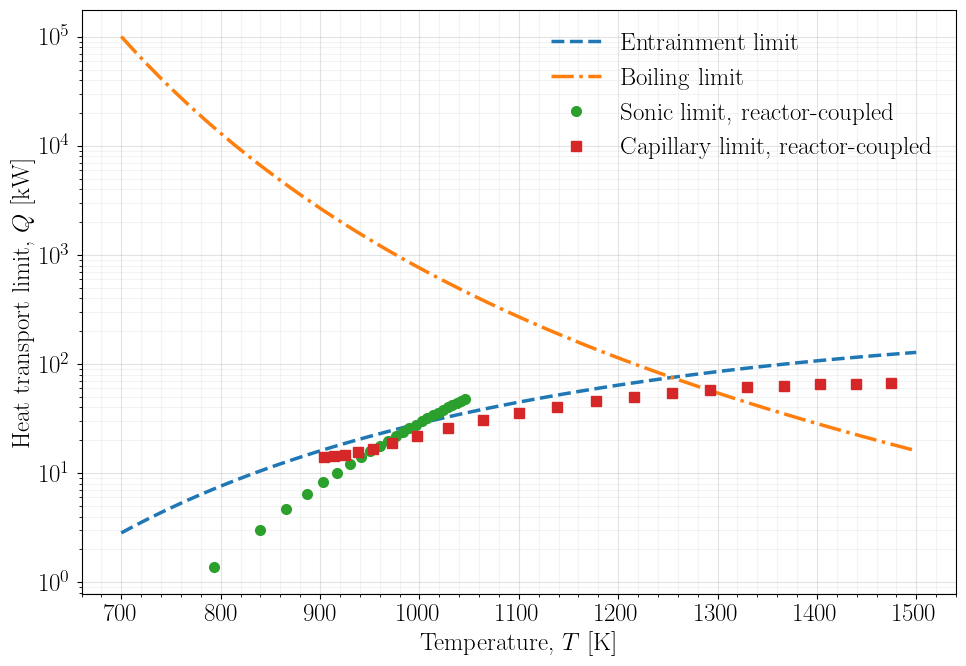

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB",
    "shamrock": "#4DA167",
    "teagreen": "#CBEFB6",
    "vanillaCustard": "#D7D9B1",
    "clay": "#EDB88B",
    "desert": "#E1BD9E",
}


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
# Old file: analytic limits + sonic numerical limit
old_data = np.load("./heatpipe_limit_curves_20260530_1848.npz", allow_pickle=True)

# New file: capillary T-sweep result from the new solver
cap_data = np.load("./capillary_T_sweep_results_20260525_1412.npz", allow_pickle=True)


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 18,
    "text.usetex": True,
})


def finite_xy(x, y):
    """Return only finite x/y pairs."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def maybe_plot_line(data, key_T, key_Q, label, *, linestyle="-", linewidth=2.5):
    """Plot a line if both keys exist."""
    if key_T in data and key_Q in data:
        T, Q = finite_xy(data[key_T], data[key_Q])
        if len(T) > 0:
            ax.plot(
                T,
                Q / 1e3,
                linestyle=linestyle,
                linewidth=linewidth,
                label=label,
            )


def maybe_plot_points(data, key_T, key_Q, label, *, marker="o", markersize=7):
    """Plot points if both keys exist."""
    if key_T in data and key_Q in data:
        T, Q = finite_xy(data[key_T], data[key_Q])
        if len(T) > 0:
            ax.plot(
                T,
                Q / 1e3,
                linestyle="none",
                marker=marker,
                markersize=markersize,
                label=label,
            )


# ------------------------------------------------------------
# Print new capillary result
# ------------------------------------------------------------
print("\nNEW CAPILLARY LIMIT FROM T-SWEEP FILE")
print("-" * 100)

T_cap = np.asarray(cap_data["T_actual"], dtype=float)
Q_cap = np.asarray(cap_data["Q_HP"], dtype=float)
P_cap = np.asarray(cap_data["P_th"], dtype=float)
h_cap = np.asarray(cap_data["h_cond"], dtype=float)
margin_cap = np.asarray(cap_data["capillary_margin"], dtype=float)
status_cap = np.asarray(cap_data["status"], dtype=str)

for T, Q, P, h, margin, status in zip(
    T_cap,
    Q_cap,
    P_cap,
    h_cap,
    margin_cap,
    status_cap,
):
    if np.isfinite(T) and np.isfinite(Q):
        print(
            f"T_actual={T:9.2f} K, "
            f"Q_HP={Q / 1e3:9.4f} kW, "
            f"P_th={P / 1e6:9.4f} MW, "
            f"h_cond={h:10.4f}, "
            f"margin={margin: .4e} Pa, "
            f"status={status}"
        )


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))


# ------------------------------------------------------------
# Analytic limits from old file
# ------------------------------------------------------------
# maybe_plot_line(
#     old_data,
#     "analytic_T",
#     "sonic_analytic_Q",
#     r"Sonic limit, analytic",
#     linestyle="-",
# )

maybe_plot_line(
    old_data,
    "analytic_T",
    "entrainment_analytic_Q",
    r"Entrainment limit",
    linestyle="--",
)

maybe_plot_line(
    old_data,
    "analytic_T",
    "boiling_analytic_Q",
    r"Boiling limit",
    linestyle="-.",
)

maybe_plot_line(
    old_data,
    "analytic_T",
    "capillary_analytic_Q",
    r"Capillary limit, analytic",
    linestyle=":",
)


# ------------------------------------------------------------
# Numerical sonic from old file
# ------------------------------------------------------------
maybe_plot_points(
    old_data,
    "sonic_numeric_T",
    "sonic_numeric_Q",
    r"Sonic limit, reactor-coupled",
    marker="o",
)


# ------------------------------------------------------------
# Numerical capillary from new T-sweep file
# ------------------------------------------------------------
maybe_plot_points(
    cap_data,
    "T_actual",
    "Q_HP",
    r"Capillary limit, reactor-coupled",
    marker="s",
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(r"Temperature, $T$ [K]")
ax.set_ylabel(r"Heat transport limit, $Q$ [kW]")

ax.set_yscale("log")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)
ax.minorticks_on()

ax.legend(
    frameon=False,
    loc="best",
)

fig.tight_layout()

plt.savefig("./heatpipe_limit_curves_with_new_capillary.png", dpi=300, bbox_inches="tight")
plt.savefig("./heatpipe_limit_curves_with_new_capillary.pdf", bbox_inches="tight")

plt.show()


NEW CAPILLARY LIMIT FROM T-SWEEP FILE
----------------------------------------------------------------------------------------------------
T_actual=   904.14 K, Q_HP=  14.1871 kW, P_th=  12.2896 MW, h_cond=  760.2509, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   914.31 K, Q_HP=  14.3874 kW, P_th=  12.4631 MW, h_cond=  716.5140, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   925.12 K, Q_HP=  14.7611 kW, P_th=  12.7868 MW, h_cond=  686.6151, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   937.76 K, Q_HP=  15.5211 kW, P_th=  13.4452 MW, h_cond=  677.2734, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   953.21 K, Q_HP=  16.8294 kW, P_th=  14.5784 MW, h_cond=  691.5480, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   972.79 K, Q_HP=  18.8707 kW, P_th=  16.3467 MW, h_cond=  732.7165, margin= 0.0000e+00 Pa, status=crossed capillary limit
T_actual=   997.93 K, Q_HP=  21.8224 kW, P_th=  18.9036 MW, h_

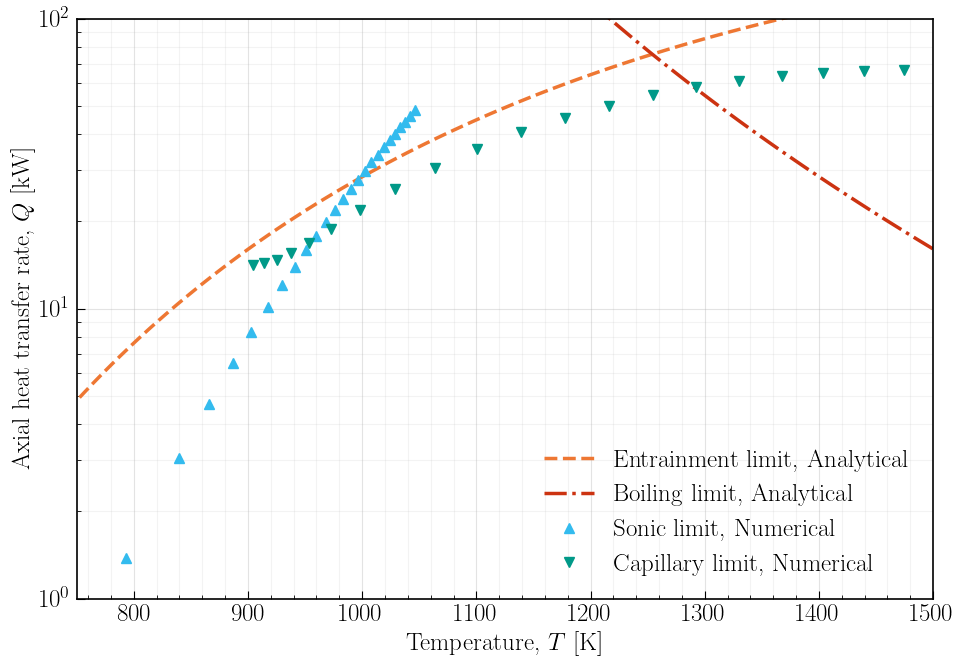

In [19]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 30,
    "text.usetex": True,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.7",
})

colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB",
    "shamrock": "#4DA167",
    "teagreen": "#CBEFB6",
    "vanillaCustard": "#D7D9B1",
    "clay": "#EDB88B",
    "desert": "#E1BD9E",
}


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
# Old file: analytic limits + sonic numerical limit
old_data = np.load("./heatpipe_limit_curves_20260530_1848.npz", allow_pickle=True)

# New file: capillary T-sweep result from the new solver
cap_data = np.load("./capillary_T_sweep_results_20260525_1412.npz", allow_pickle=True)


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 18,
    "text.usetex": True,
})


def finite_xy(x, y):
    """Return only finite x/y pairs."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def maybe_plot_line(
    data,
    key_T,
    key_Q,
    label,
    *,
    linestyle="-",
    linewidth=2.5,
    color=None,
):
    """Plot a line if both keys exist."""
    if key_T in data and key_Q in data:
        T, Q = finite_xy(data[key_T], data[key_Q])
        if len(T) > 0:
            ax.plot(
                T,
                Q / 1e3,
                linestyle=linestyle,
                linewidth=linewidth,
                color=color,
                label=label,
            )


def maybe_plot_points(
    data,
    key_T,
    key_Q,
    label,
    *,
    marker="o",
    markersize=7,
    color=None,
):
    """Plot points if both keys exist."""
    if key_T in data and key_Q in data:
        T, Q = finite_xy(data[key_T], data[key_Q])
        if len(T) > 0:
            ax.plot(
                T,
                Q / 1e3,
                linestyle="none",
                marker=marker,
                markersize=markersize,
                color=color,
                label=label,
            )


# ------------------------------------------------------------
# Print new capillary result
# ------------------------------------------------------------
print("\nNEW CAPILLARY LIMIT FROM T-SWEEP FILE")
print("-" * 100)

T_cap = np.asarray(cap_data["T_actual"], dtype=float)
Q_cap = np.asarray(cap_data["Q_HP"], dtype=float)
P_cap = np.asarray(cap_data["P_th"], dtype=float)
h_cap = np.asarray(cap_data["h_cond"], dtype=float)
margin_cap = np.asarray(cap_data["capillary_margin"], dtype=float)
status_cap = np.asarray(cap_data["status"], dtype=str)

for T, Q, P, h, margin, status in zip(
    T_cap,
    Q_cap,
    P_cap,
    h_cap,
    margin_cap,
    status_cap,
):
    if np.isfinite(T) and np.isfinite(Q):
        print(
            f"T_actual={T:9.2f} K, "
            f"Q_HP={Q / 1e3:9.4f} kW, "
            f"P_th={P / 1e6:9.4f} MW, "
            f"h_cond={h:10.4f}, "
            f"margin={margin: .4e} Pa, "
            f"status={status}"
        )


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))


# ------------------------------------------------------------
# Analytic limits from old file
# ------------------------------------------------------------
# maybe_plot_line(
#     old_data,
#     "analytic_T",
#     "sonic_analytic_Q",
#     r"Sonic limit, analytic",
#     linestyle="-",
#     color=colors["blue"],
# )

maybe_plot_line(
    old_data,
    "analytic_T",
    "entrainment_analytic_Q",
    r"Entrainment limit, Analytical",
    linestyle="--",
    color=colors["orange"],
)

maybe_plot_line(
    old_data,
    "analytic_T",
    "boiling_analytic_Q",
    r"Boiling limit,     Analytical",
    linestyle="-.",
    color=colors["red"],
)

# ------------------------------------------------------------
# Numerical sonic from old file
# ------------------------------------------------------------
maybe_plot_points(
    old_data,
    "sonic_numeric_T",
    "sonic_numeric_Q",
    r"Sonic limit,        Numerical",
    marker="^",
    color=colors["cyan"],
)


# ------------------------------------------------------------
# Numerical capillary from new T-sweep file
# ------------------------------------------------------------
maybe_plot_points(
    cap_data,
    "T_actual",
    "Q_HP",
    r"Capillary limit,    Numerical",
    marker="v",
    color=colors["teal"],
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(r"Temperature, $T$ [K]")
ax.set_ylabel(r"Axial heat transfer rate, $Q$ [kW]")

ax.set_yscale("log")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)
ax.minorticks_on()

ax.legend(
    frameon=False,
    loc="best",
)

ax.set_ylim(1e0, 1e2)
ax.set_xlim(750, 1500)

fig.tight_layout()

# plt.savefig("./heatpipe_limit_curves_with_new_capillary.png", dpi=300, bbox_inches="tight")
plt.savefig("./heatpipe_limit_curves_with_new_capillary.pdf", bbox_inches="tight")

plt.show()

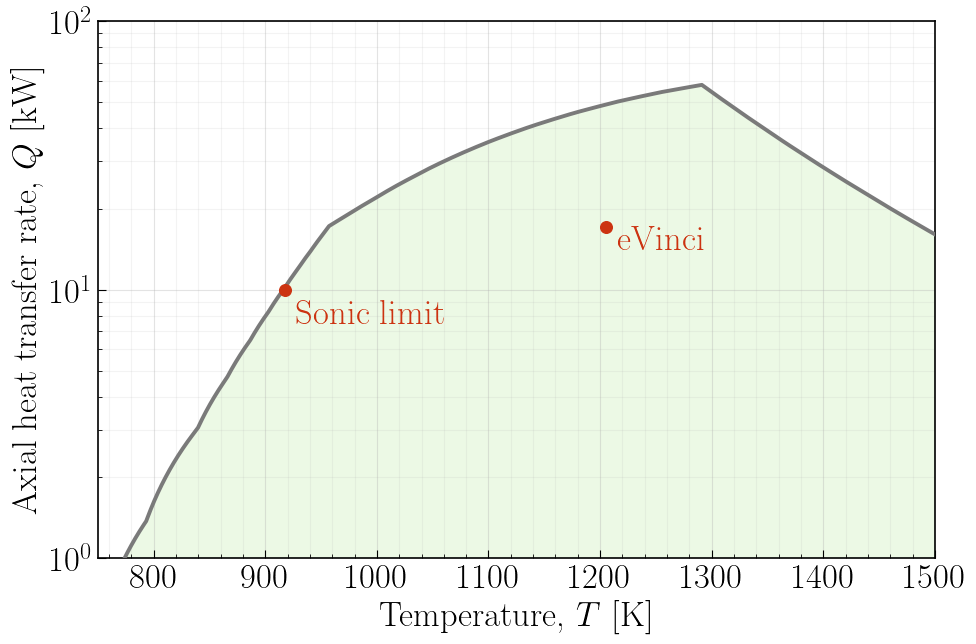

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 25,
    "text.usetex": True,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

colors = {
    "red": "#CC3311",
    "grey": "#7A7A7A",
    "light_green": "#CBEFB6",
}


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
old_data = np.load("./heatpipe_limit_curves_20260530_1848.npz", allow_pickle=True)
cap_data = np.load("./capillary_T_sweep_results_20260525_1412.npz", allow_pickle=True)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def has_key(data, key):
    return key in data.files if hasattr(data, "files") else key in data


def finite_xy(x, y, require_positive_Q=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    if require_positive_Q:
        mask &= y > 0.0

    return x[mask], y[mask]


def sort_unique_xy(T, Q):
    T = np.asarray(T, dtype=float)
    Q = np.asarray(Q, dtype=float)

    order = np.argsort(T)
    T = T[order]
    Q = Q[order]

    T_unique, inverse = np.unique(T, return_inverse=True)
    Q_unique = np.zeros_like(T_unique, dtype=float)

    for i in range(len(T_unique)):
        Q_unique[i] = np.mean(Q[inverse == i])

    return T_unique, Q_unique


def get_curve(data, key_T, key_Q):
    if not (has_key(data, key_T) and has_key(data, key_Q)):
        return None

    T, Q = finite_xy(data[key_T], data[key_Q])

    if len(T) == 0:
        return None

    T, Q = sort_unique_xy(T, Q)

    if len(T) < 2:
        return None

    return {"T": T, "Q": Q}


def build_limiting_envelope(limit_curves, n_T=3000):
    if len(limit_curves) == 0:
        raise ValueError("No limit curves were provided for the envelope.")

    T_min = min(np.min(curve["T"]) for curve in limit_curves)
    T_max = max(np.max(curve["T"]) for curve in limit_curves)

    T_grid = np.linspace(T_min, T_max, n_T)
    Q_matrix = np.full((len(limit_curves), len(T_grid)), np.nan)

    for i, curve in enumerate(limit_curves):
        T = curve["T"]
        Q = curve["Q"]

        inside = (T_grid >= np.min(T)) & (T_grid <= np.max(T))
        Q_matrix[i, inside] = np.interp(T_grid[inside], T, Q)

    valid_any = np.isfinite(Q_matrix).any(axis=0)

    Q_lim = np.full_like(T_grid, np.nan, dtype=float)
    Q_lim[valid_any] = np.nanmin(Q_matrix[:, valid_any], axis=0)

    return T_grid, Q_lim


# ------------------------------------------------------------
# Collect the individual limits for envelope construction
# These are NOT plotted, only used to compute the active contour
# ------------------------------------------------------------

limit_curves = []

curve = get_curve(old_data, "analytic_T", "entrainment_analytic_Q")
if curve is not None:
    limit_curves.append(curve)

curve = get_curve(old_data, "analytic_T", "boiling_analytic_Q")
if curve is not None:
    limit_curves.append(curve)

curve = get_curve(old_data, "sonic_numeric_T", "sonic_numeric_Q")
if curve is not None:
    # Extra sonic-limit point
    T_extra = 746.026644       # [K]
    Q_extra = 4.617605e+02     # [W]

    curve["T"] = np.append(curve["T"], T_extra)
    curve["Q"] = np.append(curve["Q"], Q_extra)
    curve["T"], curve["Q"] = sort_unique_xy(curve["T"], curve["Q"])

    limit_curves.append(curve)

curve = get_curve(cap_data, "T_actual", "Q_HP")
if curve is not None:
    limit_curves.append(curve)


# ------------------------------------------------------------
# Build limiting operating contour
# ------------------------------------------------------------
T_grid, Q_lim = build_limiting_envelope(limit_curves, n_T=3000)

valid_envelope = np.isfinite(Q_lim) & (Q_lim > 0.0)
Q_lim_kW = Q_lim / 1e3

if not np.any(valid_envelope):
    raise RuntimeError("Could not construct a valid limiting operating contour.")


# ------------------------------------------------------------
# Two operating points from other simulations
# Replace these with your actual values
# Q values should be given in W here
# ------------------------------------------------------------
T_operating = np.array([
    916,   # Simulation 1 temperature [K]
    1205,   # Simulation 2 temperature [K]
])

Q_operating = np.array([
    10e3,    # Simulation 1 axial heat transfer rate [W]
    15e6 / 876,    # Simulation 2 axial heat transfer rate [W]
])

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

q_min_kW = np.nanmin(Q_lim_kW[valid_envelope])
q_floor_kW = 10.0 ** (np.floor(np.log10(q_min_kW)) - 1.0)

# Shaded operating region
ax.fill_between(
    T_grid,
    q_floor_kW,
    Q_lim_kW,
    where=valid_envelope,
    interpolate=True,
    color=colors["light_green"],
    alpha=0.35,
    zorder=1,
)

# Operating contour
ax.plot(
    T_grid,
    Q_lim_kW,
    color=colors["grey"],
    linewidth=2.8,
    zorder=3,
)

# Operating points
ax.scatter(
    T_operating,
    Q_operating / 1e3,
    color=colors["red"],
    s=70,
    zorder=5,
)

# Optional labels for the two points
ax.text(T_operating[0] + 10, (Q_operating[0] - 25e2 ) / 1e3, r"Sonic limit", color=colors["red"])
ax.text(T_operating[1] + 10, (Q_operating[1] - 3e3 ) / 1e3, r"eVinci", color=colors["red"])


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel(r"Temperature, $T$ [K]")
ax.set_ylabel(r"Axial heat transfer rate, $Q$ [kW]")

ax.set_yscale("log")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)
ax.minorticks_on()

# Axis limits
all_q = np.concatenate([
    Q_lim_kW[valid_envelope],
    Q_operating[np.isfinite(Q_operating) & (Q_operating > 0.0)] / 1e3,
])

y_min = 1e0
y_max = 10e1

ax.set_ylim(y_min, y_max)
ax.set_xlim(750, 1500)

fig.tight_layout()

plt.savefig("./heatpipe_operating_region_only.pdf", bbox_inches="tight")

plt.show()